In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load with encoding that handles special characters
df = pd.read_csv('Sample - Superstore.csv', 
                 parse_dates=['Order Date'], 
                 encoding='latin-1')   # or encoding='cp1252'
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# TASK 1

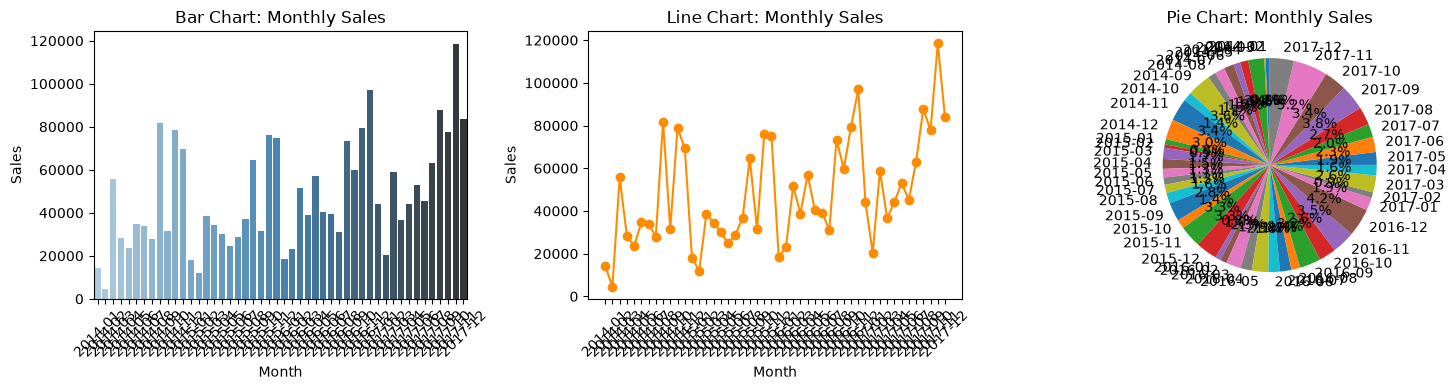

In [6]:
# Aggregate monthly sales
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Order Date'].astype(str)  # for labels

plt.figure(figsize=(15, 4))

# Bar chart
plt.subplot(1, 3, 1)
sns.barplot(data=monthly_sales, x='Month', y='Sales', palette='Blues_d')
plt.xticks(rotation=45)
plt.title('Bar Chart: Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

# Line chart
plt.subplot(1, 3, 2)
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o', color='darkorange')
plt.xticks(rotation=45)
plt.title('Line Chart: Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

# Pie chart (only first few months to avoid clutter, but we'll show all)
plt.subplot(1, 3, 3)
plt.pie(monthly_sales['Sales'], labels=monthly_sales['Month'], autopct='%1.1f%%', startangle=90)
plt.title('Pie Chart: Monthly Sales')

plt.tight_layout()
plt.show()

In [7]:
# Task 2

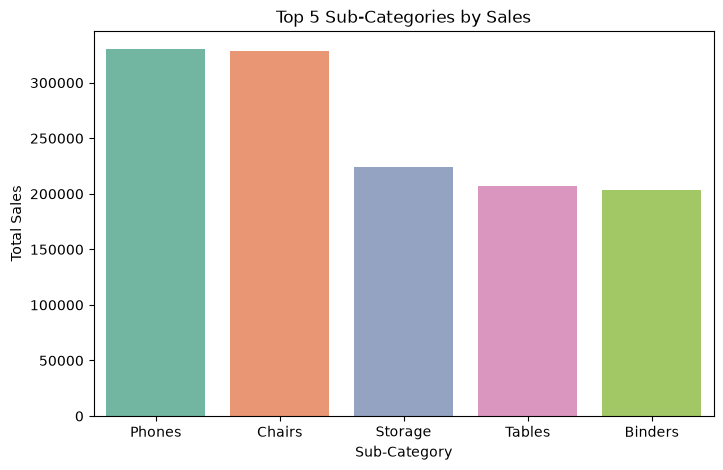

In [8]:
top5_subcat = df.groupby('Sub-Category')['Sales'].sum().nlargest(5).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=top5_subcat, x='Sub-Category', y='Sales', palette='Set2')
plt.title('Top 5 Sub-Categories by Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.show()

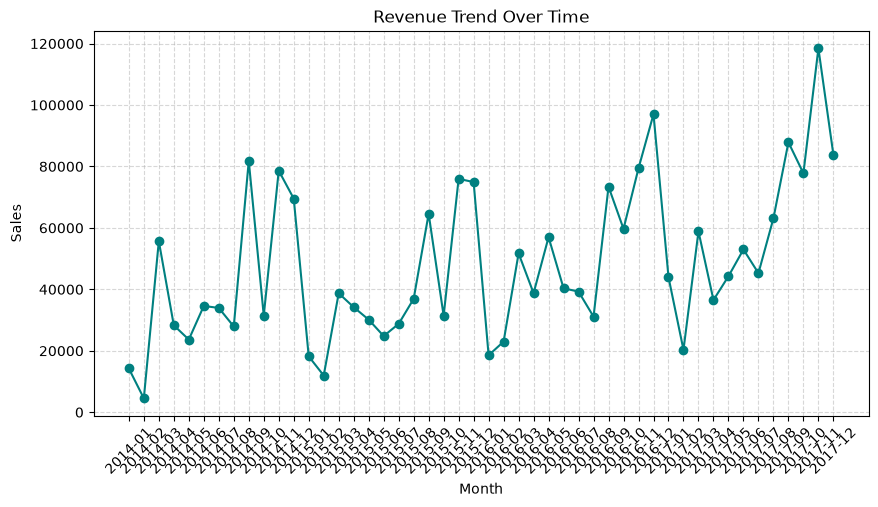

In [9]:
# Reuse monthly_sales from Task 1
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o', linestyle='-', color='teal')
plt.xticks(rotation=45)
plt.title('Revenue Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

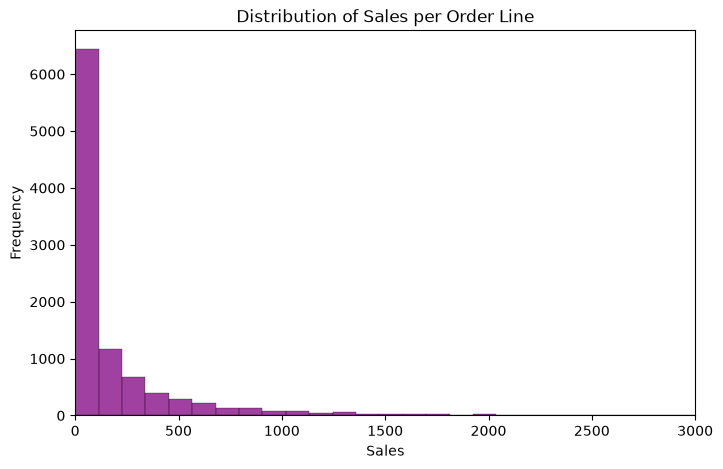

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], color='purple')
plt.title('Distribution of Sales per Order Line')
plt.xlabel('Sales')
plt.xlim(0, 3000)
plt.ylabel('Frequency')
plt.show()

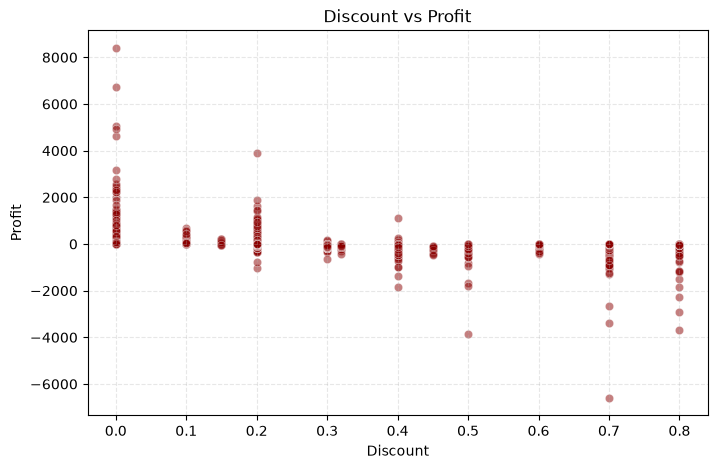

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='darkred')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [24]:
# Task 3

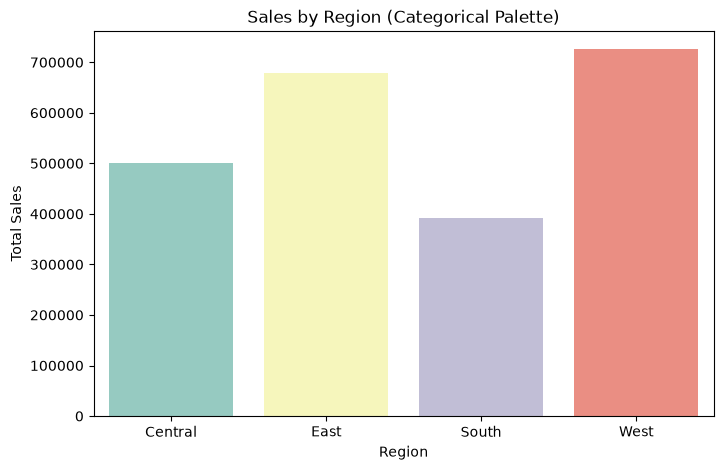

In [26]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='Set3')  # categorical palette
plt.title('Sales by Region (Categorical Palette)')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

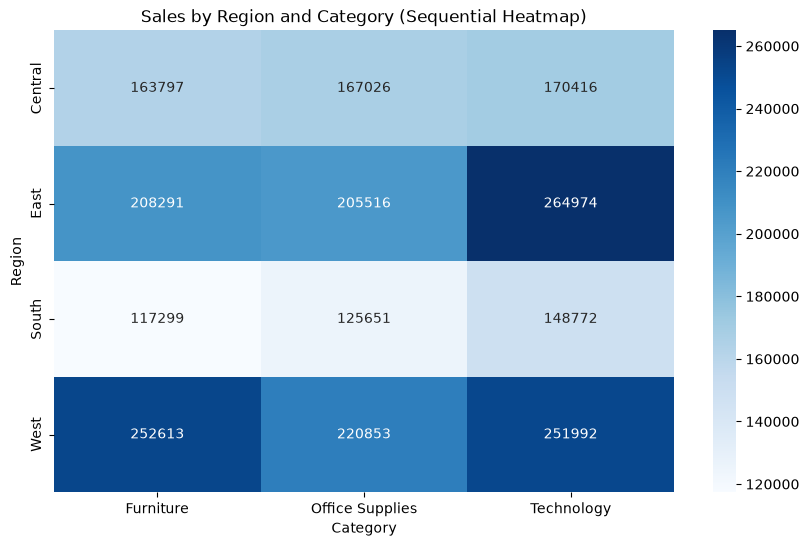

In [27]:
region_category = df.groupby(['Region', 'Category'])['Sales'].sum().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(region_category, annot=True, fmt='.0f', cmap='Blues')  # sequential
plt.title('Sales by Region and Category (Sequential Heatmap)')
plt.show()

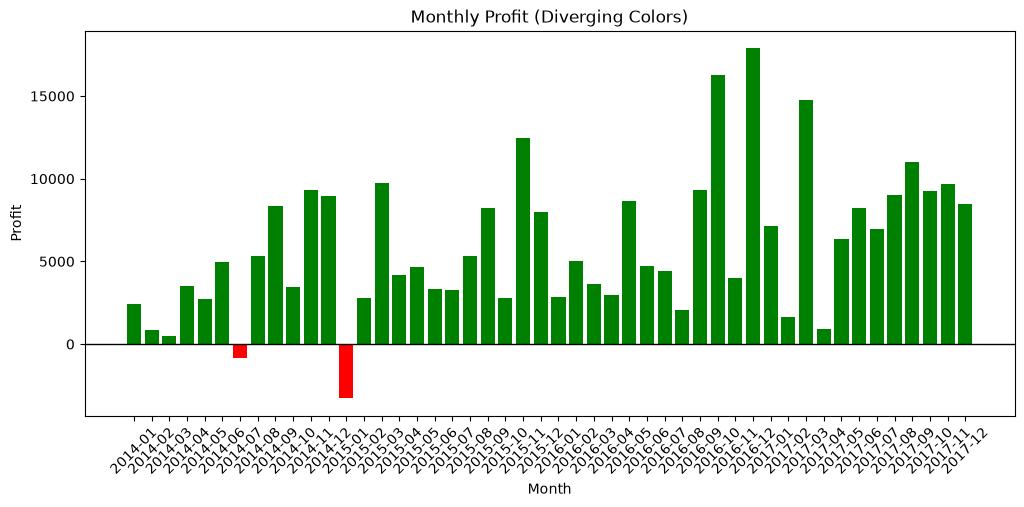

In [28]:
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum().reset_index()
monthly_profit['Month'] = monthly_profit['Order Date'].astype(str)

# Diverging bar chart: positive = green, negative = red
colors = ['green' if p >= 0 else 'red' for p in monthly_profit['Profit']]

plt.figure(figsize=(12,5))
plt.bar(monthly_profit['Month'], monthly_profit['Profit'], color=colors)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Monthly Profit (Diverging Colors)')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.show()

In [29]:
# Task 4

In [30]:
def luminance(r, g, b):
    # r,g,b in 0-255
    r_norm = r / 255.0
    g_norm = g / 255.0
    b_norm = b / 255.0
    for c in [r_norm, g_norm, b_norm]:
        if c <= 0.03928:
            c = c / 12.92
        else:
            c = ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * r_norm + 0.7152 * g_norm + 0.0722 * b_norm

def contrast_ratio(rgb1, rgb2):
    # rgb1, rgb2 are tuples (r,g,b) 0-255
    L1 = luminance(*rgb1)
    L2 = luminance(*rgb2)
    if L1 < L2:
        L1, L2 = L2, L1
    return (L1 + 0.05) / (L2 + 0.05)

# Get colors from Set3 palette (4 colors)
palette = sns.color_palette('Set3', 4)
colors_rgb = [(int(c[0]*255), int(c[1]*255), int(c[2]*255)) for c in palette]
white = (255, 255, 255)

print("Contrast ratio against white:")
for i, col in enumerate(colors_rgb):
    ratio = contrast_ratio(col, white)
    status = "PASS" if ratio >= 4.5 else "FAIL"
    print(f"Color {i+1}: {col} -> ratio = {ratio:.2f} ({status})")

Contrast ratio against white:
Color 1: (141, 211, 199) -> ratio = 1.29 (FAIL)
Color 2: (255, 255, 179) -> ratio = 1.02 (FAIL)
Color 3: (190, 186, 218) -> ratio = 1.33 (FAIL)
Color 4: (251, 128, 114) -> ratio = 1.61 (FAIL)


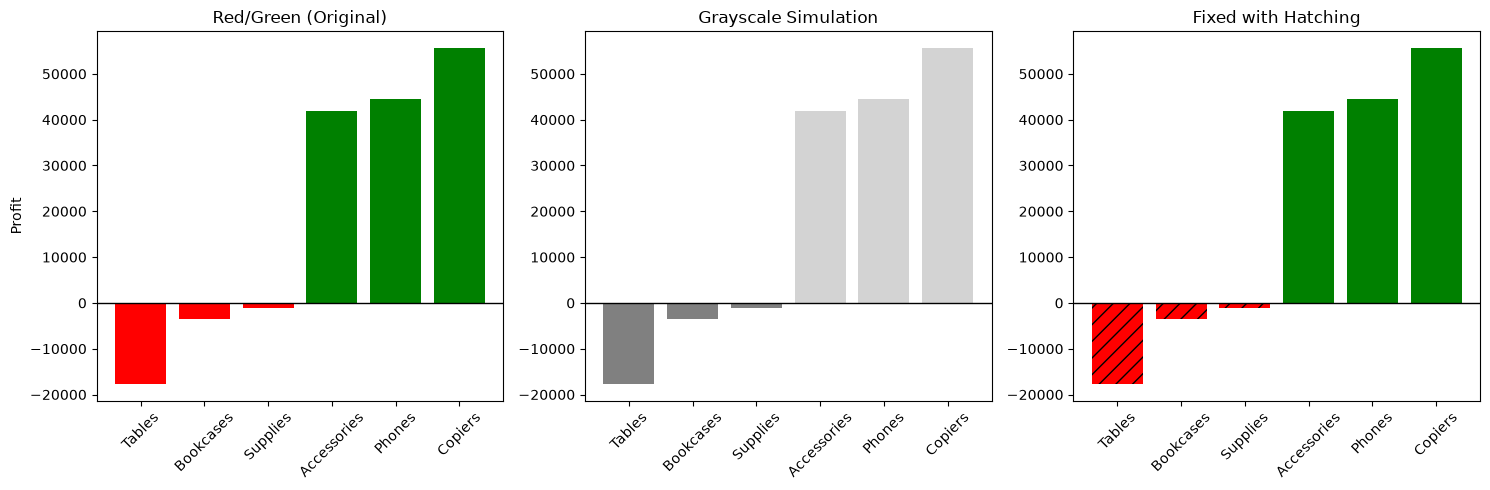

In [31]:
# Get profit by sub-category, take top and bottom few for demonstration
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
# Pick some positive and some negative
selected = pd.concat([subcat_profit.head(3), subcat_profit.tail(3)])
selected = selected.sort_values()

colors_rg = ['red' if v < 0 else 'green' for v in selected]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original red/green
axes[0].bar(selected.index, selected.values, color=colors_rg)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Red/Green (Original)')
axes[0].set_ylabel('Profit')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Grayscale simulation (using luminance conversion)
gray_colors = ['gray' if v < 0 else 'lightgray' for v in selected]  # simplified simulation
axes[1].bar(selected.index, selected.values, color=gray_colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Grayscale Simulation')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

# Fixed: add hatching to negative bars
bars = axes[2].bar(selected.index, selected.values, color=['red' if v<0 else 'green' for v in selected])
for bar, val in zip(bars, selected):
    if val < 0:
        bar.set_hatch('//')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Fixed with Hatching')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [32]:
# Task 5

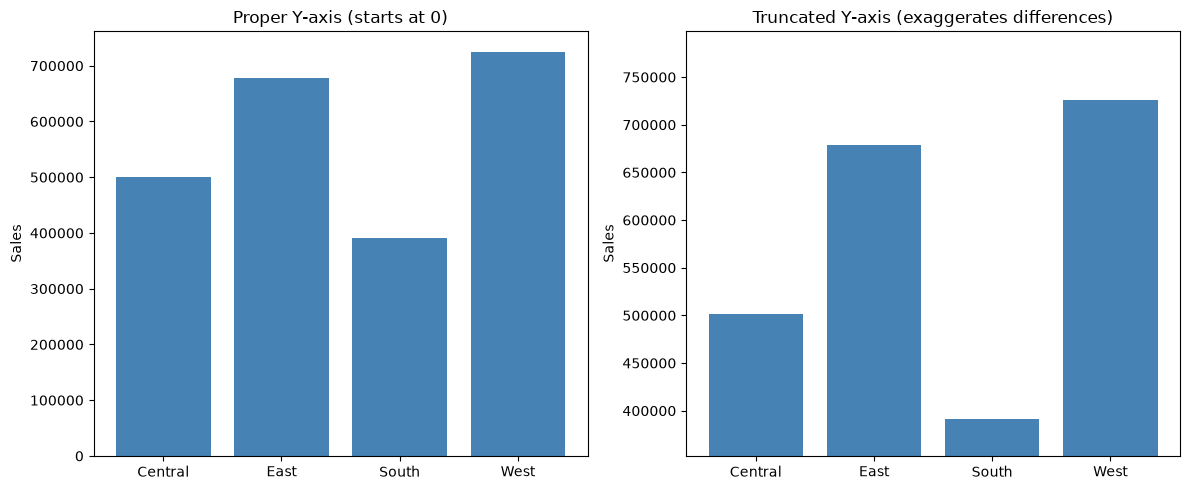

In [33]:
# Original (proper)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(region_sales['Region'], region_sales['Sales'], color='steelblue')
axes[0].set_ylim(0, None)
axes[0].set_title('Proper Y‑axis (starts at 0)')
axes[0].set_ylabel('Sales')

# Truncated
axes[1].bar(region_sales['Region'], region_sales['Sales'], color='steelblue')
axes[1].set_ylim(region_sales['Sales'].min() * 0.9, region_sales['Sales'].max() * 1.1)
axes[1].set_title('Truncated Y‑axis (exaggerates differences)')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

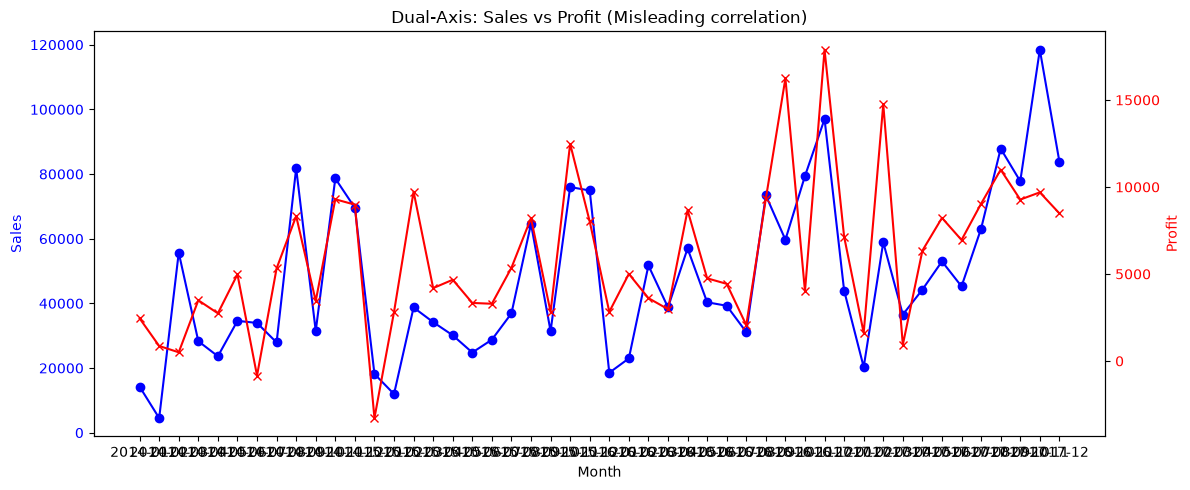

In [34]:
# Prepare monthly data
monthly = df.groupby(df['Order Date'].dt.to_period('M')).agg({'Sales':'sum', 'Profit':'sum'}).reset_index()
monthly['Month'] = monthly['Order Date'].astype(str)

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(monthly['Month'], monthly['Sales'], color='blue', marker='o', label='Sales')
ax1.set_xlabel('Month')
ax1.set_ylabel('Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(monthly['Month'], monthly['Profit'], color='red', marker='x', label='Profit')
ax2.set_ylabel('Profit', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Dual‑Axis: Sales vs Profit (Misleading correlation)')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

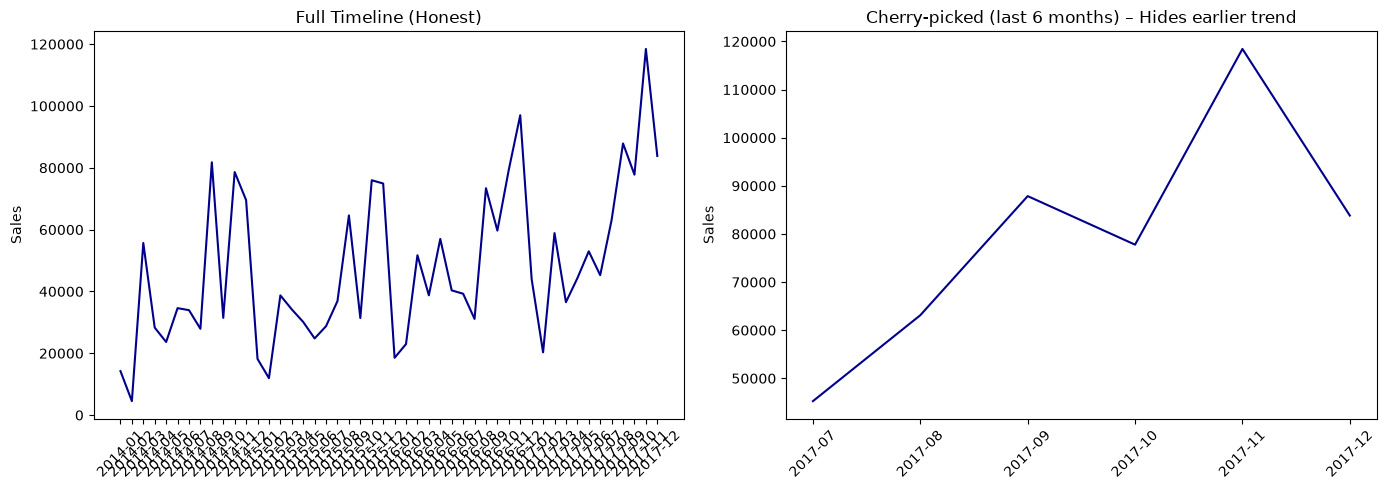

In [35]:
# Full timeline
full = monthly.copy()
# Last 6 months
cherry = full.tail(6)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(full['Month'], full['Sales'], color='darkblue')
axes[0].set_title('Full Timeline (Honest)')
axes[0].set_ylabel('Sales')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].plot(cherry['Month'], cherry['Sales'], color='darkblue')
axes[1].set_title('Cherry‑picked (last 6 months) – Hides earlier trend')
axes[1].set_ylabel('Sales')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [36]:
# Task 6

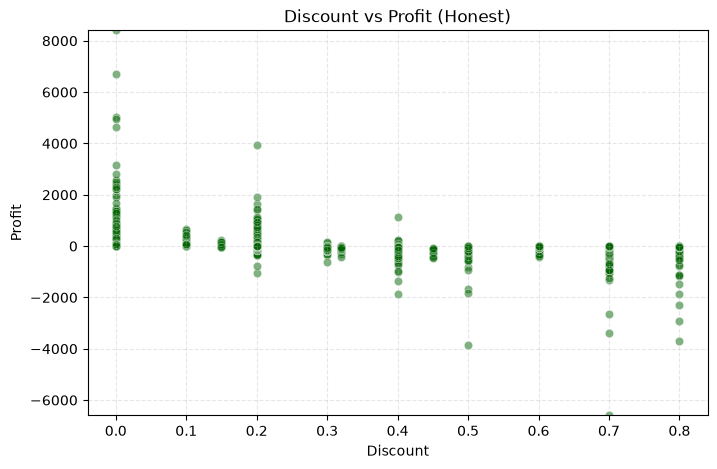

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='darkgreen')
plt.title('Discount vs Profit (Honest)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.ylim(df['Profit'].min(), df['Profit'].max())  # full range
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

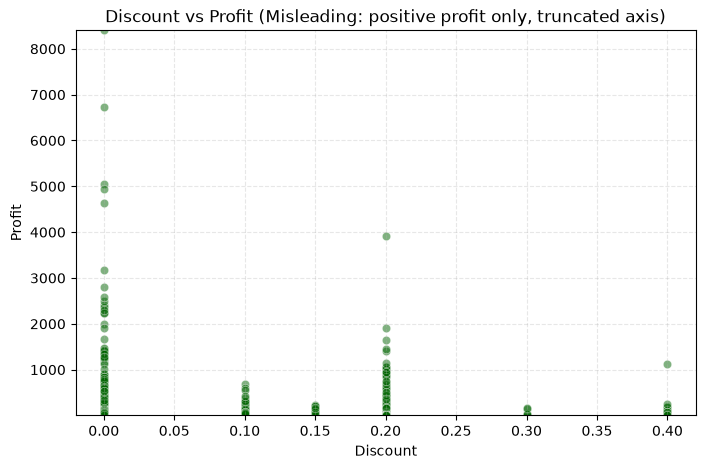

In [38]:
# Filter out negative profit to make it look like discount doesn't hurt
positive_profit = df[df['Profit'] > 0]

plt.figure(figsize=(8,5))
sns.scatterplot(data=positive_profit, x='Discount', y='Profit', alpha=0.5, color='darkgreen')
plt.title('Discount vs Profit (Misleading: positive profit only, truncated axis)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.ylim(positive_profit['Profit'].min(), positive_profit['Profit'].max())  # remove negatives
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()